# Confidence Score Analysis

Response is a 0-100 answer to a binary question (0 = strong No, 50 = neutral, 100 = strong Yes).
Confidence is defined as: "out of 100 re-analyses with different reasonable pipeline decisions, how many would give a more positive answer?"

Aggregated from `conclusion.txt` + `confidence.txt` via `scripts/aggregate_conclusions.py`.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

BASE_DIR = Path("..").resolve()
CSV_PATH = BASE_DIR / "aggregated_results" / "aggregated_results.csv"


def reflected_kde(vals, ax, color, fill=True, alpha=0.3, label=None,
                  linestyle="-", linewidth=1.5, lo=0, hi=100, n_pts=512):
    """KDE with boundary reflection on [lo, hi]."""
    v = np.asarray(vals, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 2:
        return
    reflected = np.concatenate([v, 2 * lo - v, 2 * hi - v])
    kde = gaussian_kde(reflected)
    x = np.linspace(lo, hi, n_pts)
    y = kde(x) * 3  # undo the tripling of data
    if fill:
        ax.fill_between(x, y, alpha=alpha, color=color, label=label)
        ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle)
    else:
        ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                alpha=alpha, label=label)

In [15]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected aggregated results at {CSV_PATH}. "
        "Run scripts/aggregate_conclusions.py first."
    )

df = pd.read_csv(CSV_PATH, keep_default_na=False)
df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")
datasets = sorted(df["dataset"].unique())
print(f"{len(df)} rows, {len(datasets)} datasets: {datasets}")
print(f"  confidence missing: {df['confidence'].isna().sum()}")
df.head()

2200 rows, 11 datasets: ['affairs', 'amtl', 'boxes', 'caschools', 'crofoot', 'hurricane', 'mortgage', 'panda_nuts', 'reading', 'soccer', 'teachingratings']
  confidence missing: 4


,dataset,distribution,perturbation,run_id,response,response_explanation,confidence,confidence_explanation
0,affairs,alt,add_features,1,10,The research question asks whether having chil...,80.0,The conclusion’s direction (no evidence that c...
1,affairs,alt,add_features,2,40,Among the 601 married individuals in this data...,30.0,The conclusion is based on a simple logistic m...
2,affairs,alt,add_features,3,10,Using 601 married individuals from the affairs...,65.0,The conclusion points to a strong 'No' (10) ba...
3,affairs,alt,add_features,4,40,Research question: Does having children decrea...,25.0,The analysis reports descriptive means and adj...
4,affairs,alt,add_features,5,5,Using the 1969 Psychology Today extramarital a...,80.0,The conclusion is based on a reasonable 2x2 co...


## Answer classification

In [16]:
sub = df[df["distribution"].isin(["null", "alt"])].copy()

def classify_answer(response):
    if response < 50:
        return "No"
    elif response > 50:
        return "Yes"
    return "Neutral"

sub["answer"] = sub["response"].map(classify_answer)

ct = pd.crosstab(sub["distribution"], sub["answer"], margins=True)
print(ct)
print(f"\n{(sub['answer'] == 'Neutral').sum()} neutrals dropped")

sub = sub[sub["answer"] != "Neutral"].copy()
print(f"{len(sub)} remaining")

answer        Neutral    No  Yes   All
distribution                          
alt                 5   541  554  1100
null               13  1032   55  1100
All                18  1573  609  2200

18 neutrals dropped
2182 remaining


## Confidence by distribution x answer

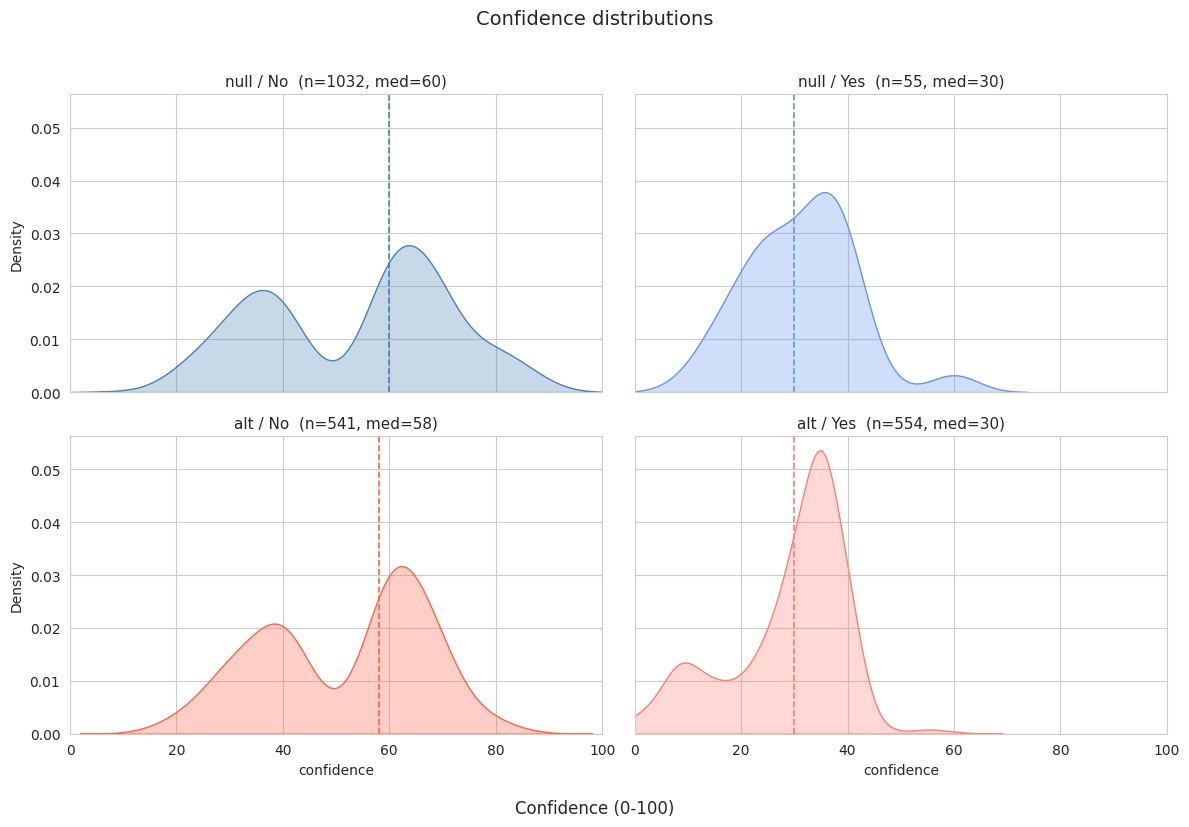

count   mean  median    std
distribution answer                             
alt          No        540  51.67    58.0  15.48
             Yes       554  28.73    30.0  10.89
null         No       1029  53.91    60.0  17.89
             Yes        55  31.15    30.0  10.15

In [17]:
group_colors = {
    ("null", "No"): "steelblue",
    ("null", "Yes"): "cornflowerblue",
    ("alt", "No"): "tomato",
    ("alt", "Yes"): "salmon",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
layout = {(0, 0): ("null", "No"), (0, 1): ("null", "Yes"),
          (1, 0): ("alt", "No"),  (1, 1): ("alt", "Yes")}

for (r, c), (dist, ans) in layout.items():
    ax = axes[r][c]
    mask = (sub["distribution"] == dist) & (sub["answer"] == ans)
    conf = sub.loc[mask, "confidence"]
    color = group_colors[(dist, ans)]
    if len(conf) > 1:
        sns.kdeplot(conf, ax=ax, color=color, fill=True, alpha=0.3, clip=(0, 100))
        ax.axvline(conf.median(), color=color, linestyle="--", linewidth=1.2)
    ax.set_title(f"{dist} / {ans}  (n={len(conf)}, med={conf.median():.0f})", fontsize=11)
    ax.set_xlim(0, 100)

fig.supxlabel("Confidence (0-100)")
fig.suptitle("Confidence distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

sub.groupby(["distribution", "answer"])["confidence"].agg(["count", "mean", "median", "std"]).round(2)

## Response vs confidence

x-axis reversed for No answers so "stronger" is always to the right.

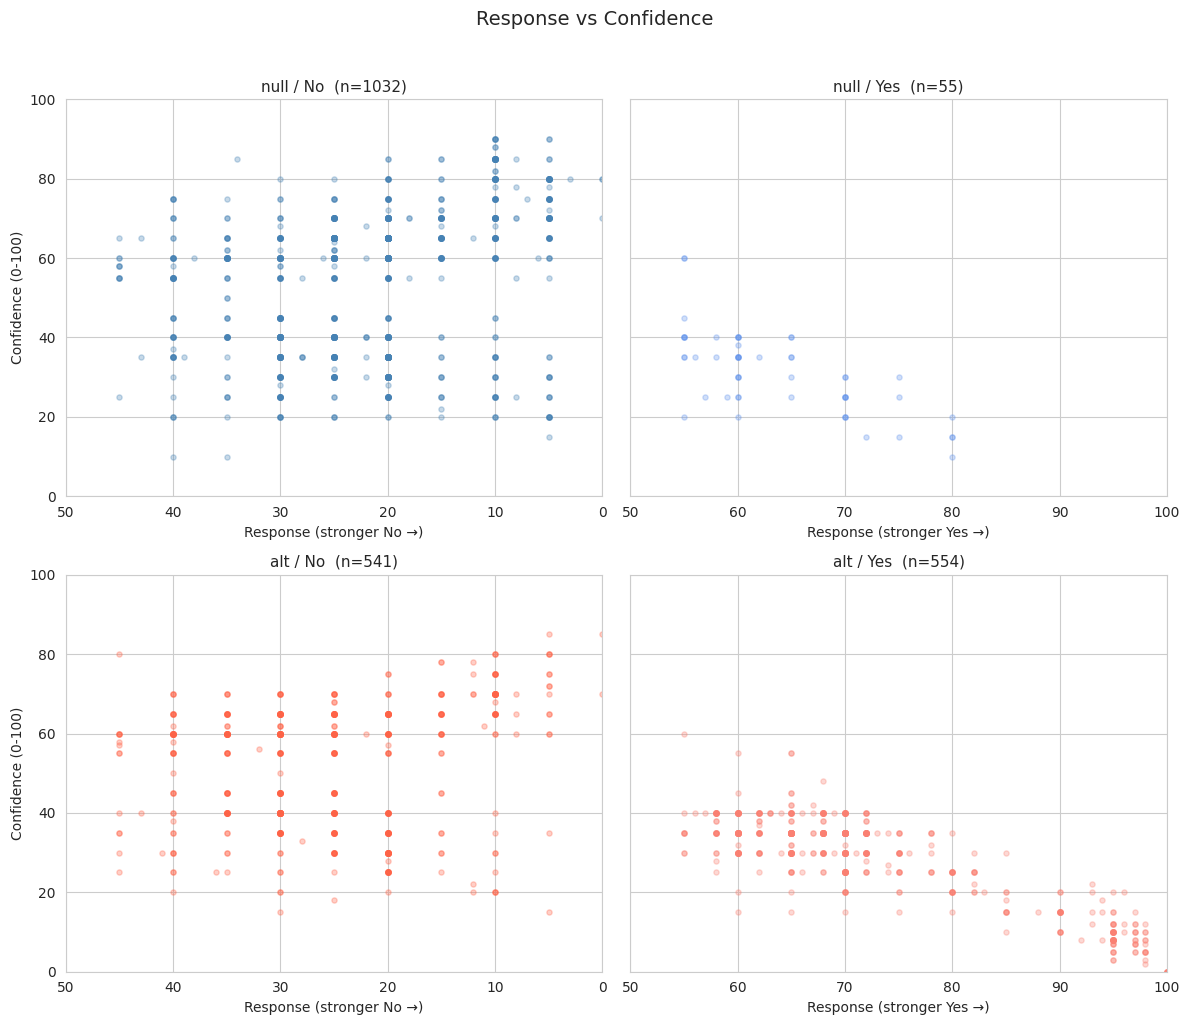

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for (r, c), (dist, ans) in layout.items():
    ax = axes[r][c]
    mask = (sub["distribution"] == dist) & (sub["answer"] == ans)
    color = group_colors[(dist, ans)]
    ax.scatter(
        sub.loc[mask, "response"],
        sub.loc[mask, "confidence"],
        alpha=0.3, s=14, color=color,
    )
    ax.set_title(f"{dist} / {ans}  (n={mask.sum()})", fontsize=11)
    ax.set_ylim(0, 100)

    if ans == "No":
        ax.set_xlim(50, 0)
        ax.set_xlabel("Response (stronger No \u2192)")
    else:
        ax.set_xlim(50, 100)
        ax.set_xlabel("Response (stronger Yes \u2192)")

axes[0][0].set_ylabel("Confidence (0-100)")
axes[1][0].set_ylabel("Confidence (0-100)")
fig.suptitle("Response vs Confidence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Per-dataset confidence, split by answer

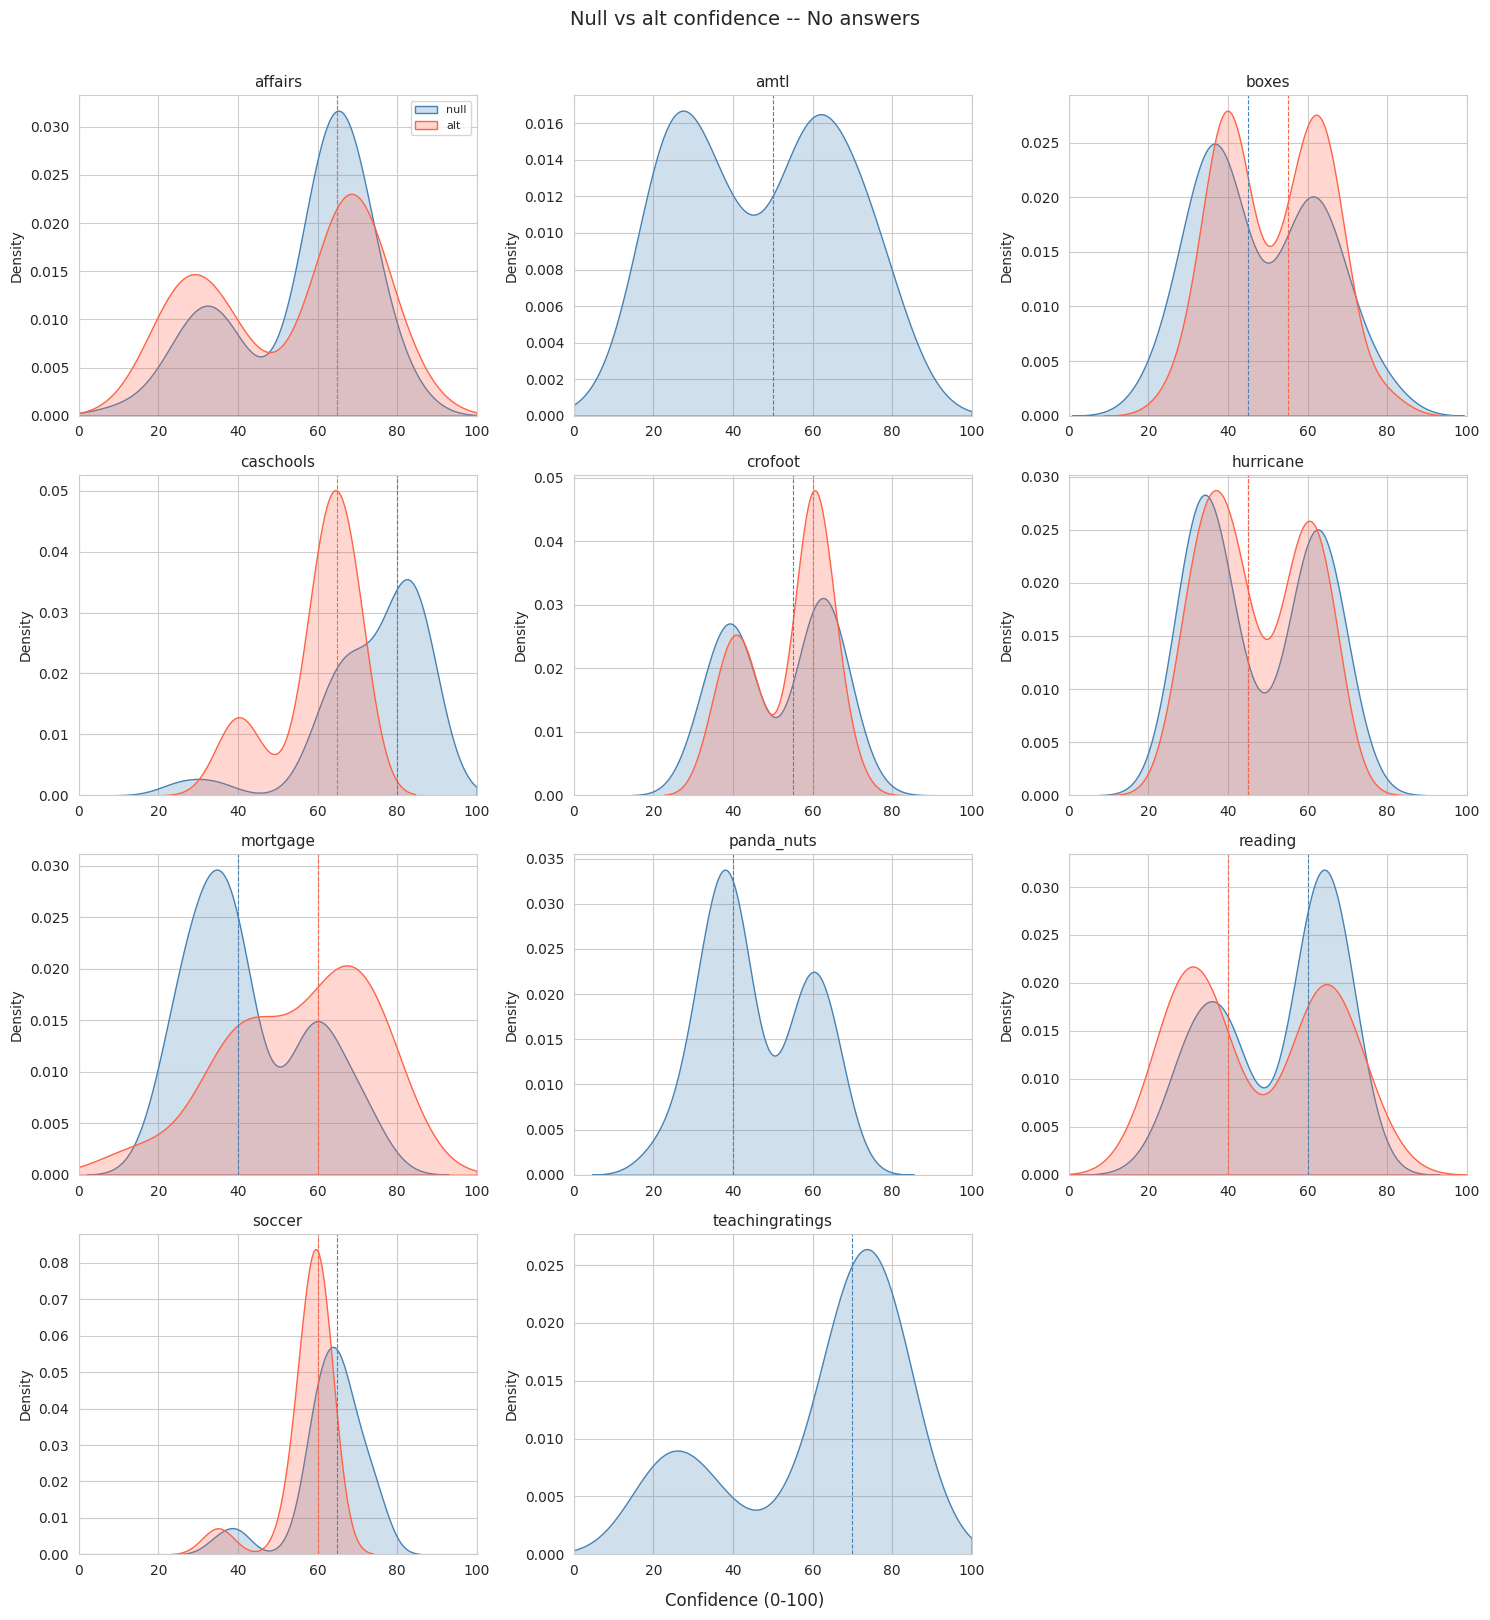

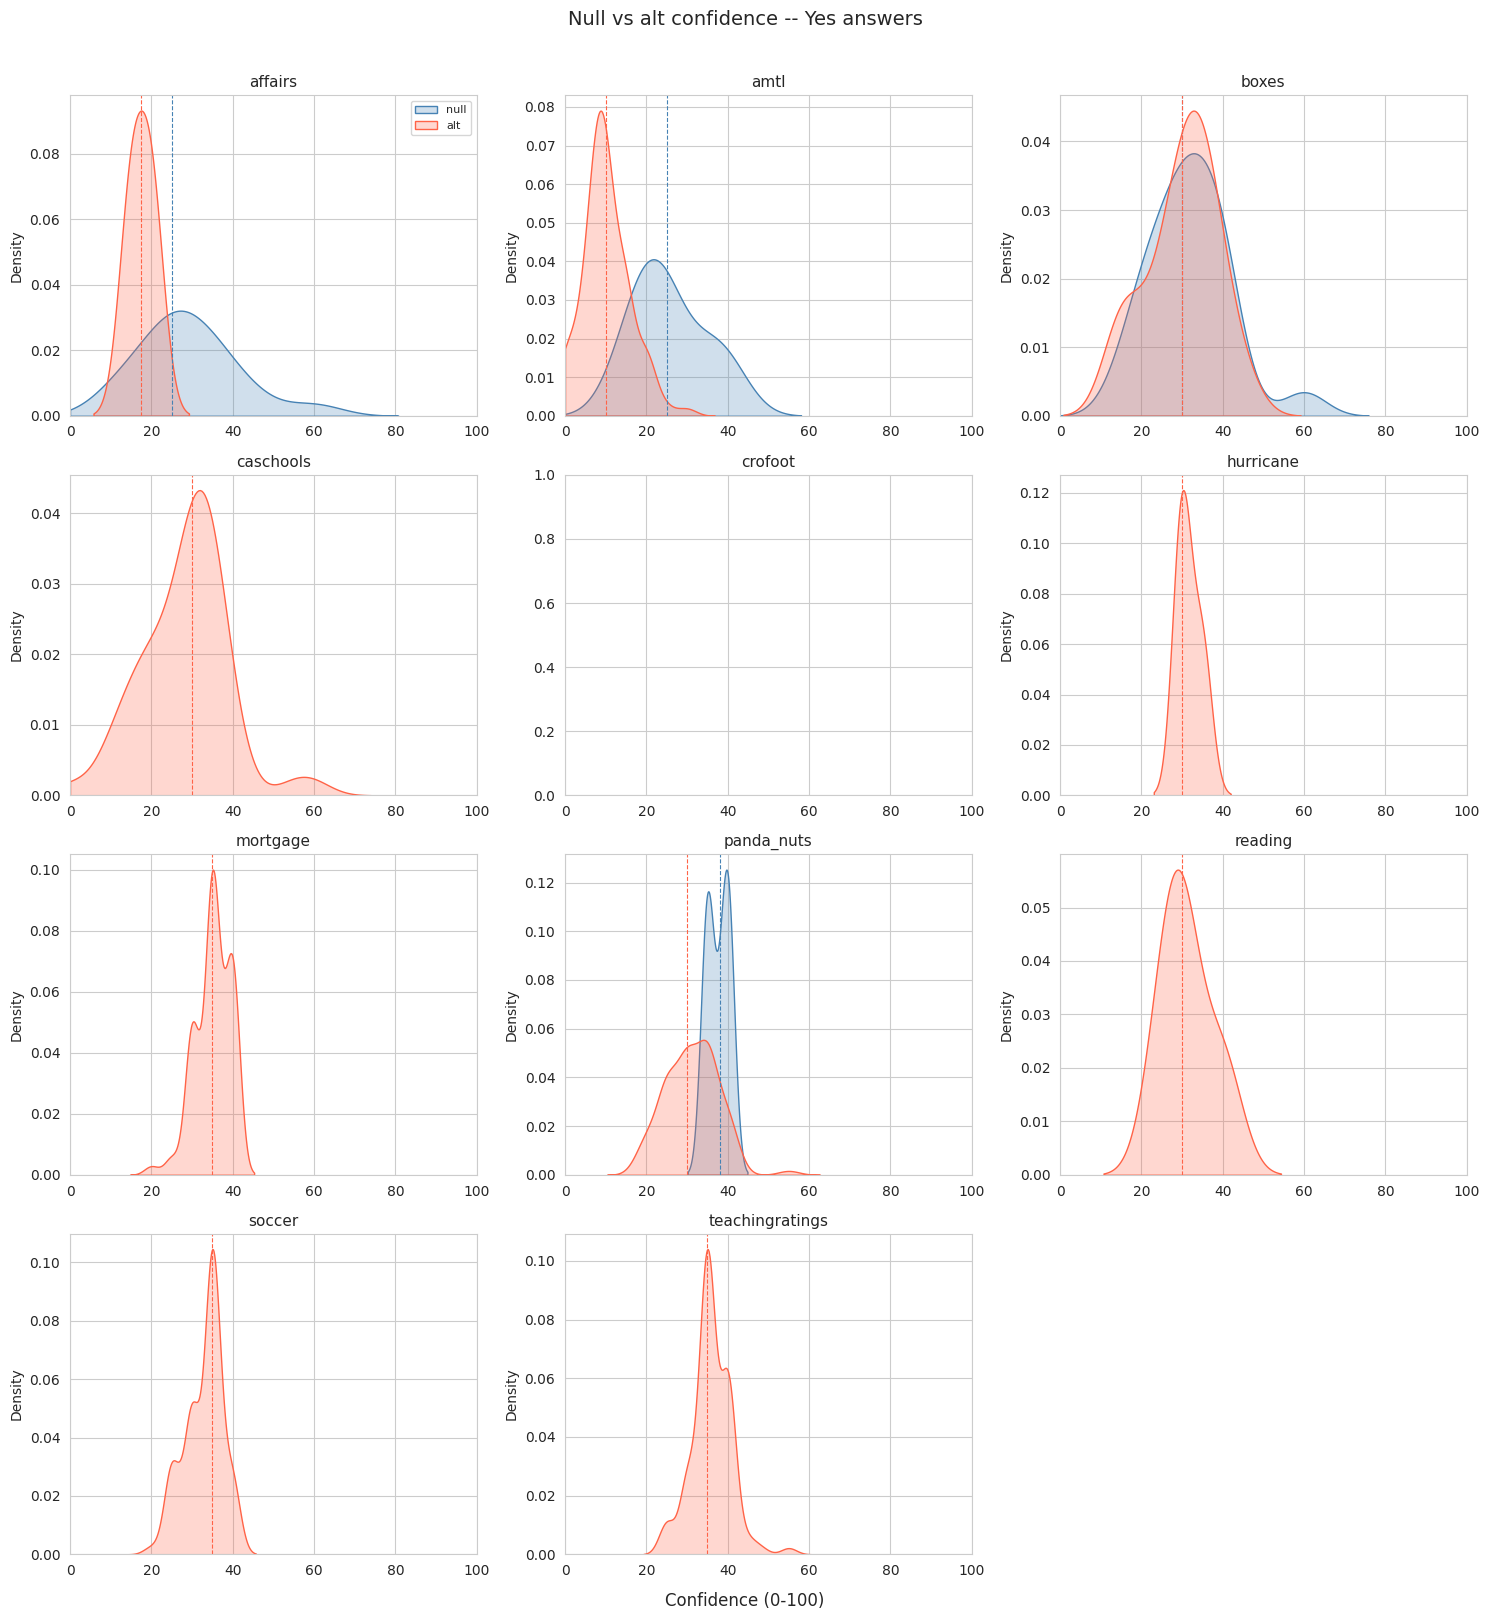

In [19]:
dist_palette = {"null": "steelblue", "alt": "tomato"}
n_datasets = len(datasets)
n_cols = 3
n_rows = int(np.ceil(n_datasets / n_cols))

for ans in ["No", "Yes"]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=False)
    axes = axes.flatten()

    for i, dataset_name in enumerate(datasets):
        ax = axes[i]
        ds = sub[(sub["dataset"] == dataset_name) & (sub["answer"] == ans)]
        for dist, color in dist_palette.items():
            vals = ds.loc[ds["distribution"] == dist, "confidence"]
            if len(vals) > 1:
                sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.25,
                            label=dist, clip=(0, 100), common_norm=False)
                ax.axvline(vals.median(), color=color, linestyle="--", linewidth=0.8)
        ax.set_title(dataset_name, fontsize=11)
        ax.set_xlim(0, 100)
        ax.set_xlabel("")
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.supxlabel("Confidence (0-100)")
    fig.suptitle(f"Null vs alt confidence -- {ans} answers", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## Perturbation effects

Dashed lines = pooled across all perturbations (reference).

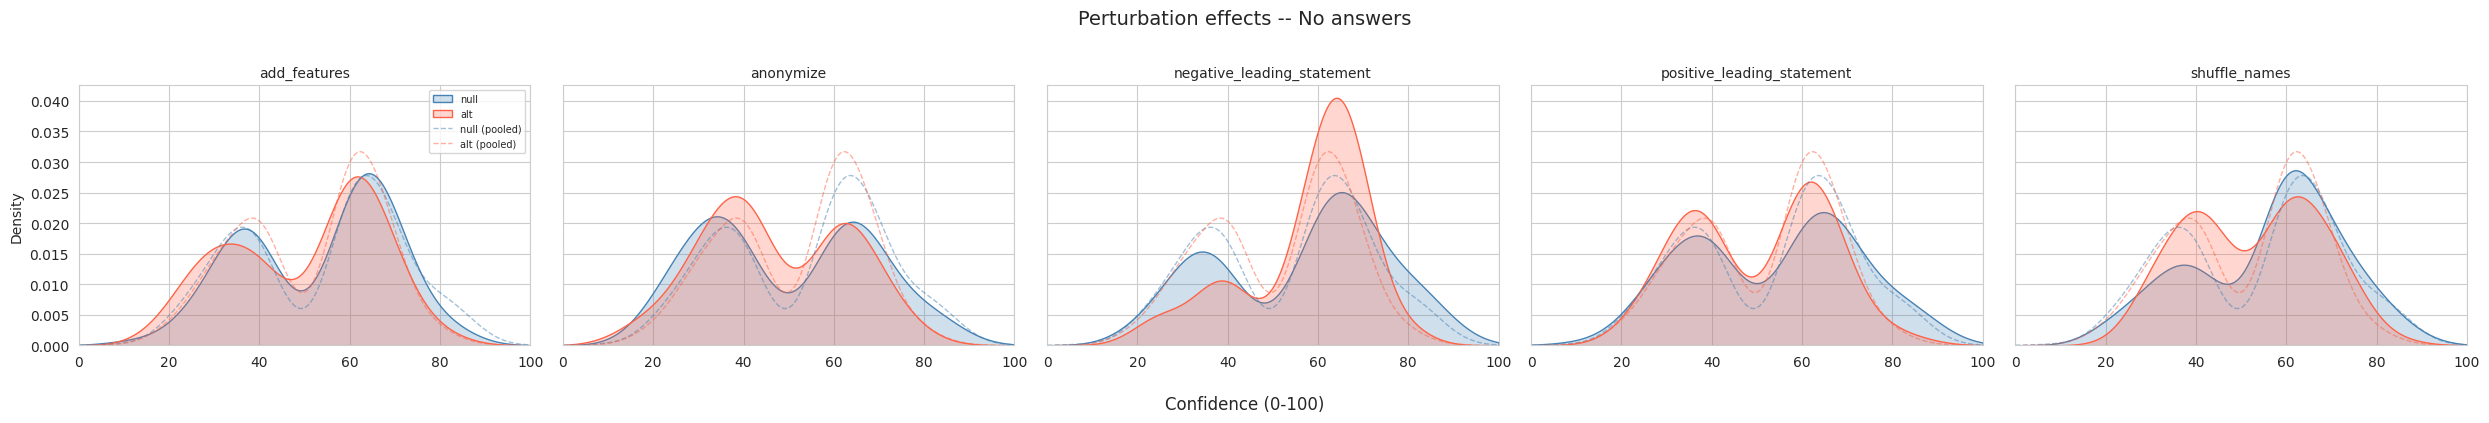

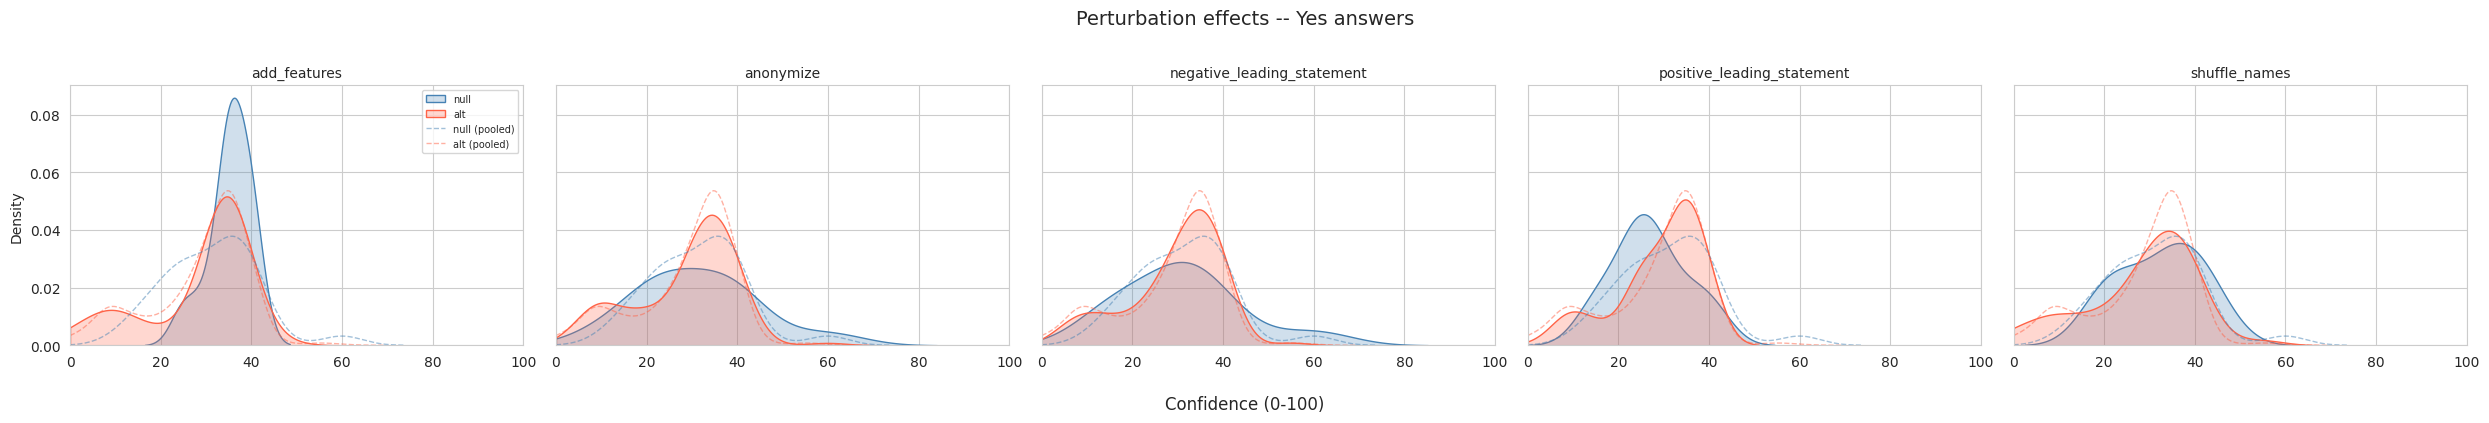

In [20]:
perturbations = sorted(sub["perturbation"].unique())

for ans in ["No", "Yes"]:
    fig, axes = plt.subplots(1, len(perturbations),
                             figsize=(5 * len(perturbations), 4), sharey=True)

    ans_mask = sub["answer"] == ans
    for i, pert in enumerate(perturbations):
        ax = axes[i]
        ps = sub[(sub["perturbation"] == pert) & ans_mask]

        for dist, color in dist_palette.items():
            vals = ps.loc[ps["distribution"] == dist, "confidence"]
            if len(vals) > 1:
                sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.25,
                            label=dist, clip=(0, 100), common_norm=False)

        # pooled reference
        for dist, color in dist_palette.items():
            pooled = sub.loc[ans_mask & (sub["distribution"] == dist), "confidence"]
            if len(pooled) > 1:
                sns.kdeplot(pooled, ax=ax, color=color, linestyle="--", linewidth=1,
                            alpha=0.5, clip=(0, 100), common_norm=False,
                            label=f"{dist} (pooled)" if i == 0 else None)

        ax.set_title(pert, fontsize=10)
        ax.set_xlim(0, 100)
        ax.set_xlabel("")

    axes[0].legend(fontsize=7)
    fig.supxlabel("Confidence (0-100)")
    fig.suptitle(f"Perturbation effects -- {ans} answers", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Bimodality in "No" confidence

The "No" confidence distribution looks bimodal. Conditioning on various factors to see what's causing it.

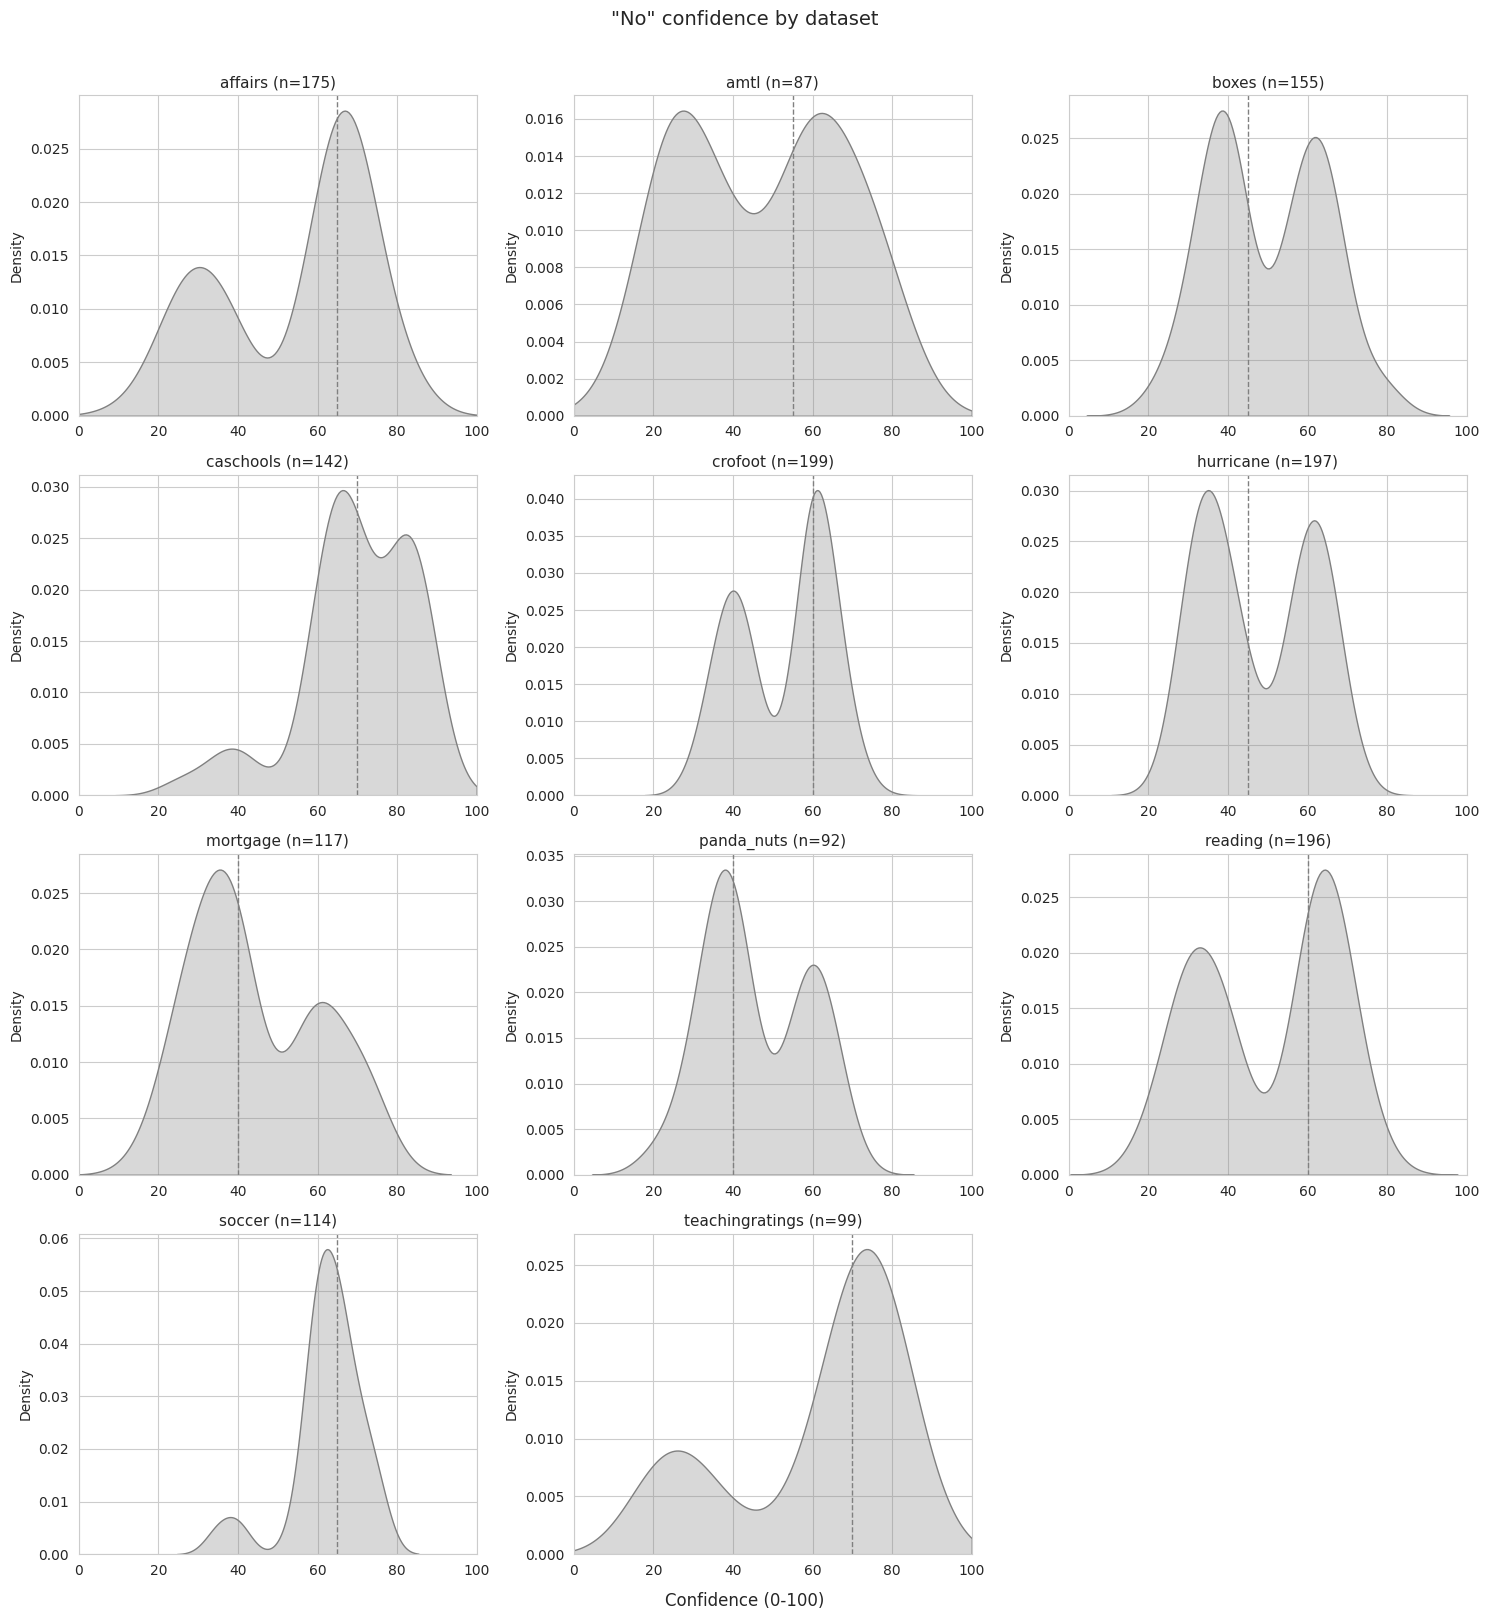

In [21]:
no_sub = sub[sub["answer"] == "No"].copy()

# by dataset
n_cols = 3
n_rows = int(np.ceil(n_datasets / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=False)
axes = axes.flatten()

for i, dataset_name in enumerate(datasets):
    ax = axes[i]
    vals = no_sub.loc[no_sub["dataset"] == dataset_name, "confidence"]
    if len(vals) > 1:
        sns.kdeplot(vals, ax=ax, color="gray", fill=True, alpha=0.3, clip=(0, 100))
        ax.axvline(vals.median(), color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{dataset_name} (n={len(vals)})", fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.supxlabel("Confidence (0-100)")
fig.suptitle('"No" confidence by dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

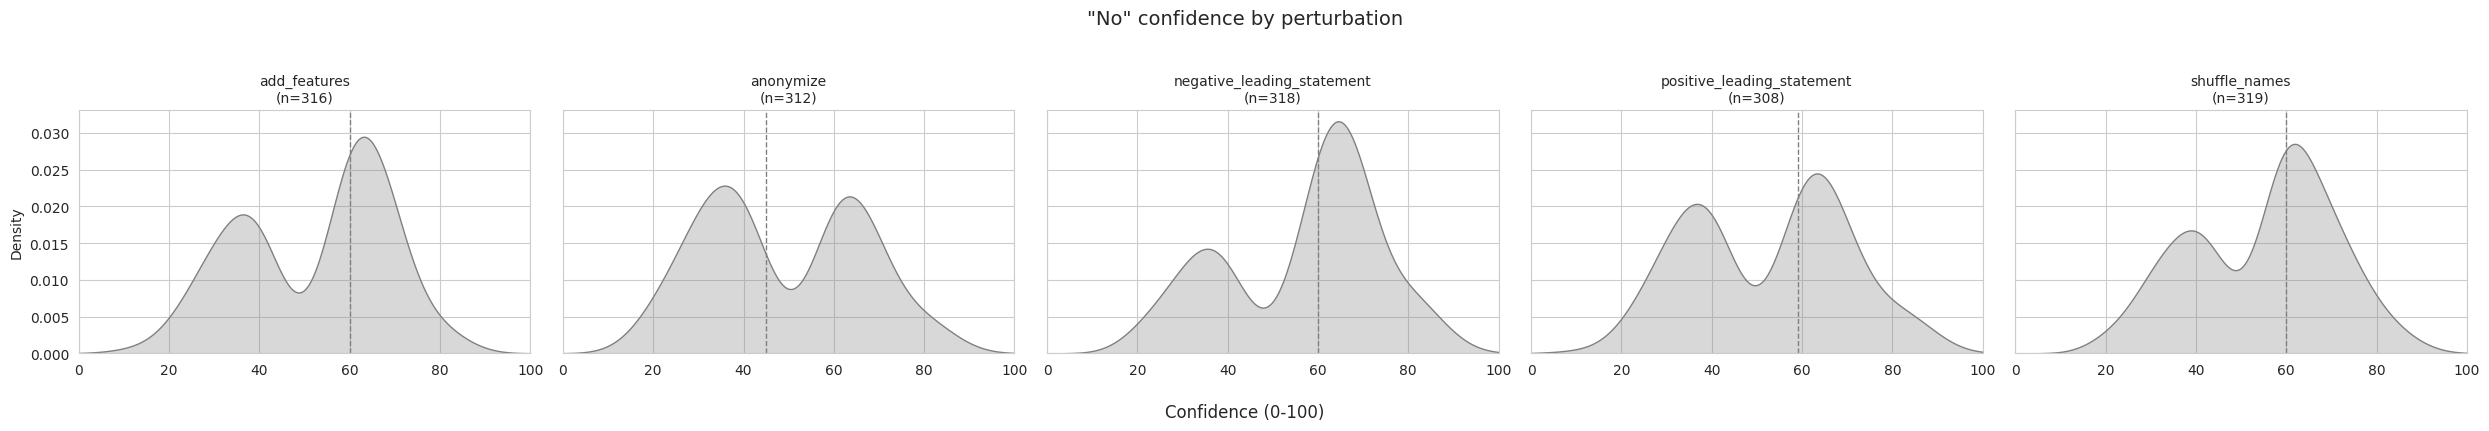

In [22]:
# by perturbation
fig, axes = plt.subplots(1, len(perturbations), figsize=(5 * len(perturbations), 4), sharey=True)

for i, pert in enumerate(perturbations):
    ax = axes[i]
    vals = no_sub.loc[no_sub["perturbation"] == pert, "confidence"]
    if len(vals) > 1:
        sns.kdeplot(vals, ax=ax, color="gray", fill=True, alpha=0.3, clip=(0, 100))
        ax.axvline(vals.median(), color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{pert}\n(n={len(vals)})", fontsize=10)
    ax.set_xlim(0, 100)
    ax.set_xlabel("")

fig.supxlabel("Confidence (0-100)")
fig.suptitle('"No" confidence by perturbation', fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

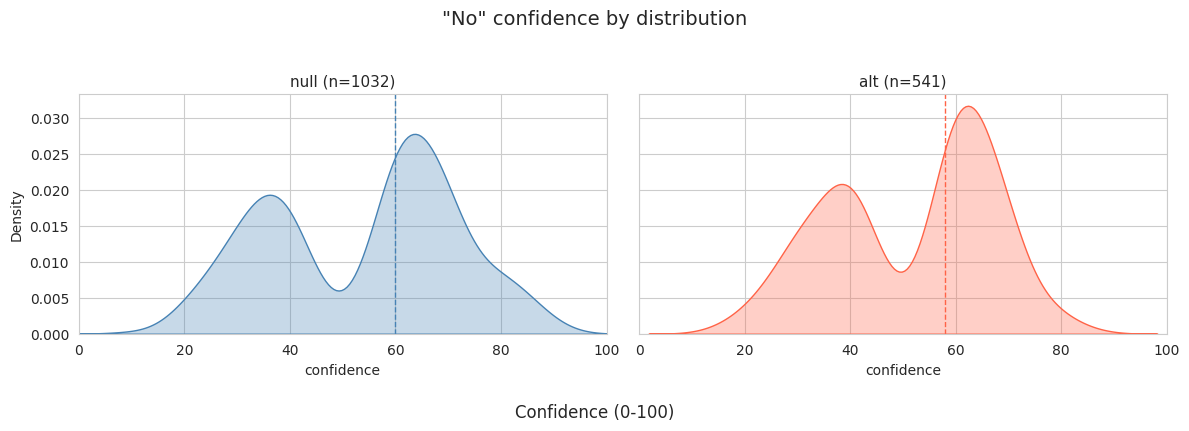

In [23]:
# by distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, dist in zip(axes, ["null", "alt"]):
    vals = no_sub.loc[no_sub["distribution"] == dist, "confidence"]
    if len(vals) > 1:
        sns.kdeplot(vals, ax=ax, color=dist_palette[dist], fill=True, alpha=0.3, clip=(0, 100))
        ax.axvline(vals.median(), color=dist_palette[dist], linestyle="--", linewidth=1)
    ax.set_title(f"{dist} (n={len(vals)})", fontsize=11)
    ax.set_xlim(0, 100)

fig.supxlabel("Confidence (0-100)")
fig.suptitle('"No" confidence by distribution', fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

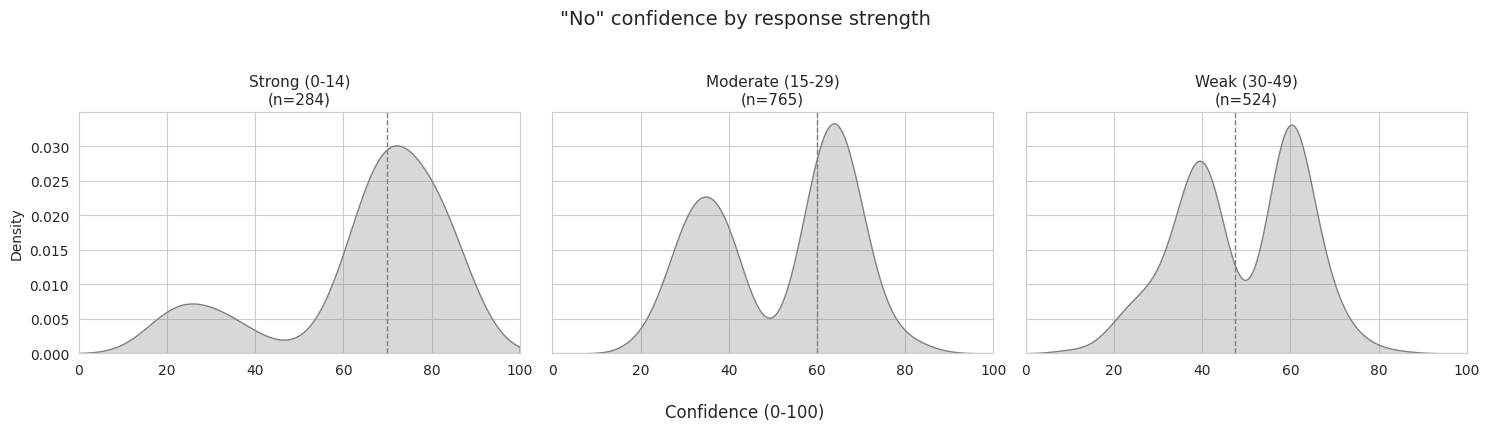

In [24]:
# by response strength
def no_strength(resp):
    if resp >= 30:
        return "Weak (30-49)"
    elif resp >= 15:
        return "Moderate (15-29)"
    return "Strong (0-14)"

no_sub["strength"] = no_sub["response"].map(no_strength)
strength_order = ["Strong (0-14)", "Moderate (15-29)", "Weak (30-49)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, strength in zip(axes, strength_order):
    vals = no_sub.loc[no_sub["strength"] == strength, "confidence"]
    if len(vals) > 1:
        sns.kdeplot(vals, ax=ax, color="gray", fill=True, alpha=0.3, clip=(0, 100))
        ax.axvline(vals.median(), color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{strength}\n(n={len(vals)})", fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_xlabel("")

fig.supxlabel("Confidence (0-100)")
fig.suptitle('"No" confidence by response strength', fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

## Response-confidence correlation

In [25]:
for ans in ["No", "Yes"]:
    print(f"--- {ans} answers ---")
    corr_rows = []
    for dataset_name in datasets:
        mask = (sub["dataset"] == dataset_name) & (sub["answer"] == ans)
        s = sub.loc[mask]
        if len(s) > 2:
            resp = (50 - s["response"]) if ans == "No" else s["response"]
            rho, _ = stats.spearmanr(resp, s["confidence"])
            corr_rows.append({"dataset": dataset_name, "n": len(s), "spearman_rho": round(rho, 3)})
    corr_df = pd.DataFrame(corr_rows)

    all_mask = sub["answer"] == ans
    all_s = sub.loc[all_mask]
    resp_all = (50 - all_s["response"]) if ans == "No" else all_s["response"]
    rho_all, _ = stats.spearmanr(resp_all, all_s["confidence"])
    overall = pd.DataFrame([{"dataset": "OVERALL", "n": all_mask.sum(), "spearman_rho": round(rho_all, 3)}])
    corr_df = pd.concat([corr_df, overall], ignore_index=True)
    print(corr_df.to_string(index=False))
    print()

--- No answers ---
        dataset    n  spearman_rho
        affairs  175         0.629
           amtl   87         0.329
          boxes  155           NaN
      caschools  142         0.544
        crofoot  199           NaN
      hurricane  197           NaN
       mortgage  117        -0.063
     panda_nuts   92        -0.192
        reading  196         0.093
         soccer  114         0.383
teachingratings   99         0.178
        OVERALL 1573           NaN

--- Yes answers ---
        dataset   n  spearman_rho
        affairs  19        -0.701
           amtl 106        -0.739
          boxes  42        -0.607
      caschools  57        -0.698
      hurricane   3         0.500
       mortgage  83        -0.216
     panda_nuts 108        -0.722
        reading   4         0.500
         soccer  86        -0.418
teachingratings 100        -0.393
        OVERALL 609        -0.676



## Confidence vs response p-value

Each run's confidence score plotted against the response permutation-test p-value for its dataset. Since p-values are per-dataset, there are 11 distinct x-positions.

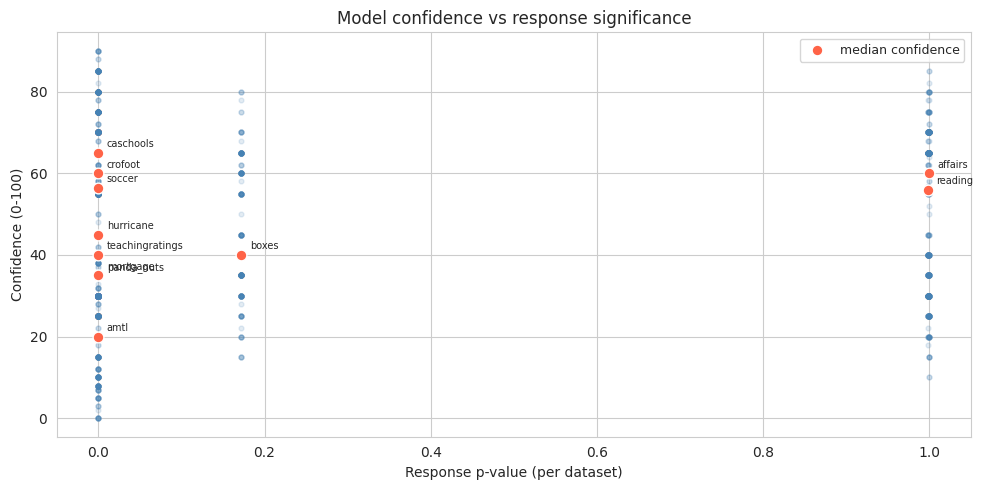

        dataset        p  med_conf
           amtl 0.000100      20.0
      caschools 0.000100      65.0
        crofoot 0.000100      60.0
      hurricane 0.000100      45.0
       mortgage 0.000100      35.0
     panda_nuts 0.000100      35.0
         soccer 0.000100      56.5
teachingratings 0.000100      40.0
          boxes 0.172183      40.0
        reading 0.998800      56.0
        affairs 1.000000      60.0


In [26]:
# compute per-dataset response p-values (unblocked difference in means)
import sys as _sys
_scripts_dir = str(BASE_DIR / "scripts")
if _scripts_dir not in _sys.path:
    _sys.path.insert(0, _scripts_dir)
from statistical_tests import blocked_permutation_test

perm_rng = np.random.default_rng(42)
dataset_pvals = {}
for name in datasets:
    ds = df[df["dataset"] == name]
    _, p, _ = blocked_permutation_test(ds, "response", n_perm=10_000, agg=np.mean, rng=perm_rng)
    dataset_pvals[name] = p

df_plot = df[df["distribution"].isin(["null", "alt"])].copy()
df_plot["response_pvalue"] = df_plot["dataset"].map(dataset_pvals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    df_plot["response_pvalue"],
    df_plot["confidence"],
    alpha=0.15, s=12, color="steelblue",
)

# overlay per-dataset median confidence
med_conf = df_plot.groupby("dataset").agg(
    p=("response_pvalue", "first"),
    med_conf=("confidence", "median"),
).reset_index()
ax.scatter(med_conf["p"], med_conf["med_conf"], s=60, color="tomato",
           edgecolor="white", zorder=5, label="median confidence")
for _, row in med_conf.iterrows():
    ax.annotate(row["dataset"], (row["p"], row["med_conf"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7)

ax.set_xlabel("Response p-value (per dataset)")
ax.set_ylabel("Confidence (0-100)")
ax.set_title("Model confidence vs response significance")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(med_conf[["dataset", "p", "med_conf"]].sort_values(by="p").to_string(index=False))